<a href="https://colab.research.google.com/github/pcmouadji-dot/deep_learning/blob/main/Customer_Churn(dl).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import numpy as pd
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [85]:
data=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
train_x,test_x,train_y,test_y=train_test_split(data.drop('Churn',axis=1),data['Churn'],test_size=0.2,random_state=18)
scaler=StandardScaler()

# HANDELING ,ENCODING AND SCALING DATA

In [86]:
train_y=train_y.map({'Yes':1,'No':0})
test_y=test_y.map({'Yes':1,'No':0})
train_x["Partner"]=train_x["Partner"].map({'Yes':1,'No':0})
test_x["Partner"]=test_x["Partner"].map({'Yes':1,'No':0})
train_x["Dependents"]=train_x["Dependents"].map({'Yes':1,'No':0})
test_x["Dependents"]=test_x["Dependents"].map({'Yes':1,'No':0})
train_x["PhoneService"]=train_x["PhoneService"].map({'Yes':1,'No':0})
test_x["PhoneService"]=test_x["PhoneService"].map({'Yes':1,'No':0})
train_x["PaperlessBilling"]=train_x["PaperlessBilling"].map({'Yes':1,'No':0})
test_x["PaperlessBilling"]=test_x["PaperlessBilling"].map({'Yes':1,'No':0})
train_x["MultipleLines"]=train_x["MultipleLines"].map({'Yes':1,'No':0,'No phone service':2})
test_x["MultipleLines"]=test_x["MultipleLines"].map({'Yes':1,'No':0,'No phone service':2})
train_x["OnlineSecurity"]=train_x["OnlineSecurity"].map({'Yes':1,'No':0,'No internet service':2})
test_x["OnlineSecurity"]=test_x["OnlineSecurity"].map({'Yes':1,'No':0,'No internet service':2})
train_x["OnlineBackup"]=train_x["OnlineBackup"].map({'Yes':1,'No':0,'No internet service':2})
test_x["OnlineBackup"]=test_x["OnlineBackup"].map({'Yes':1,'No':0,'No internet service':2})
train_x["DeviceProtection"]=train_x["DeviceProtection"].map({'Yes':1,'No':0,'No internet service':2})
test_x["DeviceProtection"]=test_x["DeviceProtection"].map({'Yes':1,'No':0,'No internet service':2})
train_x["TechSupport"]=train_x["TechSupport"].map({'Yes':1,'No':0,'No internet service':2})
test_x["TechSupport"]=test_x["TechSupport"].map({'Yes':1,'No':0,'No internet service':2})
train_x["StreamingTV"]=train_x["StreamingTV"].map({'Yes':1,'No':0,'No internet service':2})
test_x["StreamingTV"]=test_x["StreamingTV"].map({'Yes':1,'No':0,'No internet service':2})
train_x["StreamingMovies"]=train_x["StreamingMovies"].map({'Yes':1,'No':0,'No internet service':2})
test_x["StreamingMovies"]=test_x["StreamingMovies"].map({'Yes':1,'No':0,'No internet service':2})
train_x["Contract"]=train_x["Contract"].map({'Month-to-month':1,'One year':2,'Two year':3})
test_x["Contract"]=test_x["Contract"].map({'Month-to-month':1,'One year':2,'Two year':3})
train_x["PaymentMethod"]=train_x["PaymentMethod"].map({'Electronic check':1,'Mailed check':2,'Bank transfer (automatic)':3,'Credit card (automatic)':4})
test_x["PaymentMethod"]=test_x["PaymentMethod"].map({'Electronic check':1,'Mailed check':2,'Bank transfer (automatic)':3,'Credit card (automatic)':4})
train_x.drop(columns=["customerID"],inplace=True)
test_x.drop(columns=["customerID"],inplace=True)
train_x["InternetService"]=train_x["InternetService"].map({'Fiber optic':2,'DSL':1,'No':0})
test_x["InternetService"]=test_x["InternetService"].map({'Fiber optic':2,'DSL':1,'No':0})
train_x["TotalCharges"]=pd.to_numeric(train_x["TotalCharges"],errors='coerce')
test_x["TotalCharges"]=pd.to_numeric(test_x["TotalCharges"],errors='coerce')
train_x["TotalCharges"]=train_x["TotalCharges"].fillna(train_x["TotalCharges"].mean())
test_x["TotalCharges"]=test_x["TotalCharges"].fillna(test_x["TotalCharges"].mean())
train_x=pd.get_dummies(train_x,columns=["gender"],dtype=int)
test_x=pd.get_dummies(test_x,columns=["gender"],dtype=int)
display(train_x)
train_x=scaler.fit_transform(train_x)
test_x=scaler.transform(test_x)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender_Female,gender_Male
5658,0,1,0,24,1,1,2,0,0,0,0,1,1,1,1,1,93.00,2248.05,0,1
783,0,0,0,1,1,0,1,0,0,0,1,0,0,1,1,1,52.20,52.20,1,0
1836,0,0,0,24,1,0,2,0,0,0,1,1,1,1,1,1,96.00,2122.45,0,1
545,0,1,1,34,1,0,2,0,0,0,0,0,1,2,1,3,78.95,2647.20,0,1
3609,0,0,0,61,1,1,2,0,1,1,0,1,1,2,1,1,103.95,6423.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,0,1,0,30,1,1,1,0,0,0,0,0,0,1,0,1,49.90,1441.95,0,1
2885,1,0,0,67,1,1,2,1,1,1,1,1,1,3,1,4,116.10,7839.85,0,1
1144,0,0,0,1,0,2,1,0,0,0,0,0,1,1,1,1,35.55,35.55,0,1
4371,0,1,1,13,1,1,0,2,2,2,2,2,2,2,0,3,24.50,343.60,0,1


In [87]:
temp=pd.DataFrame(train_x)
temp

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.432556,1.037626,-0.655428,-0.334388,0.326587,0.583290,0.994004,-0.899634,-1.009229,-0.994004,-0.906882,0.242744,0.240223,-0.826516,0.83547,-1.138646,0.929907,-0.017914,-0.986951,0.986951
1,-0.432556,-0.963738,-0.655428,-1.271005,0.326587,-0.943781,-0.293107,-0.899634,-1.009229,-0.994004,0.353447,-1.072273,-1.076330,-0.826516,0.83547,-1.138646,-0.425956,-0.983482,1.013222,-1.013222
2,-0.432556,-0.963738,-0.655428,-0.334388,0.326587,-0.943781,0.994004,-0.899634,-1.009229,-0.994004,0.353447,0.242744,0.240223,-0.826516,0.83547,-1.138646,1.029603,-0.073143,-0.986951,0.986951
3,-0.432556,1.037626,1.525720,0.072836,0.326587,-0.943781,0.994004,-0.899634,-1.009229,-0.994004,-0.906882,-1.072273,0.240223,0.374875,0.83547,0.606731,0.462999,0.157602,-0.986951,0.986951
4,-0.432556,-0.963738,-0.655428,1.172343,0.326587,0.583290,0.994004,-0.899634,0.283043,0.293107,-0.906882,0.242744,0.240223,0.374875,0.83547,-1.138646,1.293797,1.817913,1.013222,-1.013222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,-0.432556,1.037626,-0.655428,-0.090053,0.326587,0.583290,-0.293107,-0.899634,-1.009229,-0.994004,-0.906882,-1.072273,-1.076330,-0.826516,-1.19693,-1.138646,-0.502389,-0.372376,-0.986951,0.986951
5630,2.311838,-0.963738,-0.655428,1.416677,0.326587,0.583290,0.994004,0.358692,0.283043,0.293107,0.353447,0.242744,0.240223,1.576266,0.83547,1.479419,1.697565,2.440936,-0.986951,0.986951
5631,-0.432556,-0.963738,-0.655428,-1.271005,-3.061975,2.110361,-0.293107,-0.899634,-1.009229,-0.994004,-0.906882,-1.072273,0.240223,-0.826516,0.83547,-1.138646,-0.979267,-0.990804,-0.986951,0.986951
5632,-0.432556,1.037626,1.525720,-0.782335,0.326587,0.583290,-1.580218,1.617018,1.575315,1.580218,1.613775,1.557761,1.556775,0.374875,-1.19693,0.606731,-1.346480,-0.855347,-0.986951,0.986951


# BUILDING THE MODEL

In [88]:
model=keras.Sequential([
    keras.layers.Dense(32,input_shape=(20,),activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_x,train_y,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6628 - loss: 0.5897
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7721 - loss: 0.4699
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7847 - loss: 0.4482
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7888 - loss: 0.4417
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7890 - loss: 0.4401
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4359
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.4360
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7957 - loss: 0.4320
Epoch 9/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4309
Epoch 10/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7961 - loss: 0.4295
Epoch 11/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7973 - loss: 0.4312
Epoch 12/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

# predicting/evaluating

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


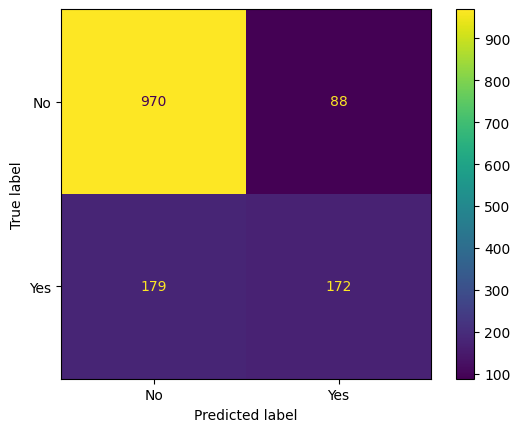

In [89]:
prediction=model.predict(test_x)
prediction=prediction.round().astype(int)
cmd=ConfusionMatrixDisplay(confusion_matrix(test_y,prediction),display_labels=['No','Yes'])
cmd.plot()

# random forest

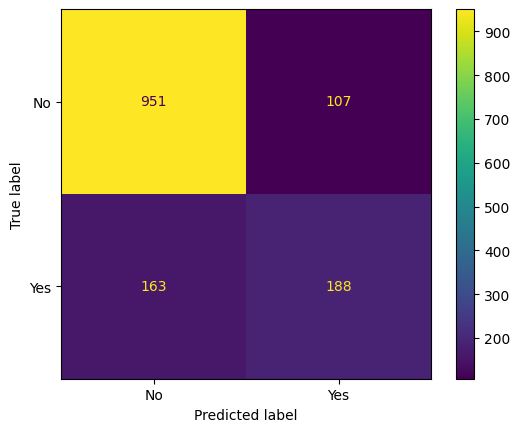

In [90]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100)
model.fit(train_x,train_y)
prediction=model.predict(test_x)
prediction=prediction.round().astype(int)
cmd=ConfusionMatrixDisplay(confusion_matrix(test_y,prediction),display_labels=['No','Yes'])
cmd.plot()